### HR ANALYTICS

IMPORT LIBRARIES

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style = "whitegrid")
sns.set_palette("deep")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["font.size"] = 12

from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages("hr_analytics_report.pdf")

LOAD DATASET

In [36]:
data = pd.read_csv("hr_analytics.csv")
print(data)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

DATA OVERVIEW

In [37]:
print(data.shape)

(1470, 35)


In [38]:
print(data.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


In [39]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [40]:
print(data.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

DATA CLEANING

In [41]:
print(data.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [42]:
print(data["EmployeeNumber"].duplicated().sum())

0


In [43]:
print(data.drop_duplicates())

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

EXPLORATORY DATA ANALYSIS

1 . ATTRITION ANALYSIS

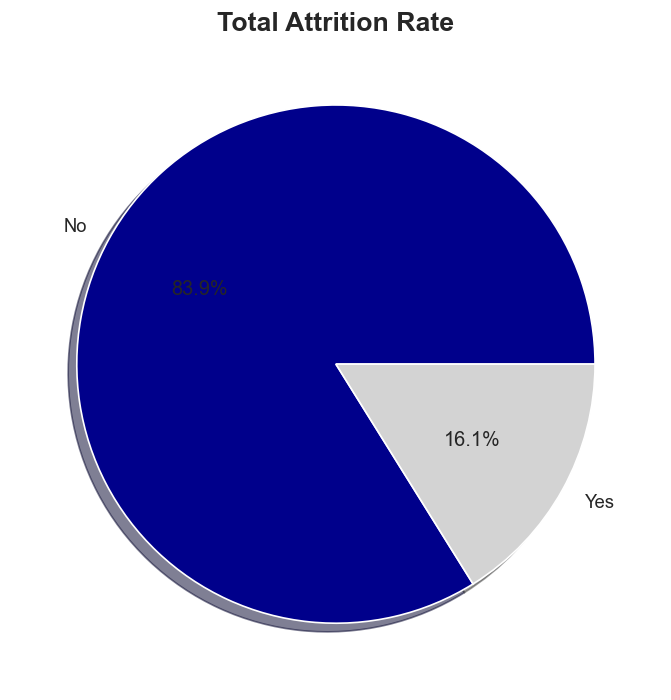

In [44]:
# Count the values of column
tot_attrition = data["Attrition"].value_counts(normalize=True)*100

# Plot the chart
colors = ["darkblue","lightgrey"]
plt.figure(figsize = (6,6))
tot_attrition.plot(kind = "pie",autopct = "%.1f%%",shadow = True,colors = colors)
plt.title("Total Attrition Rate")

plt.tight_layout()
pdf.savefig()
plt.show()

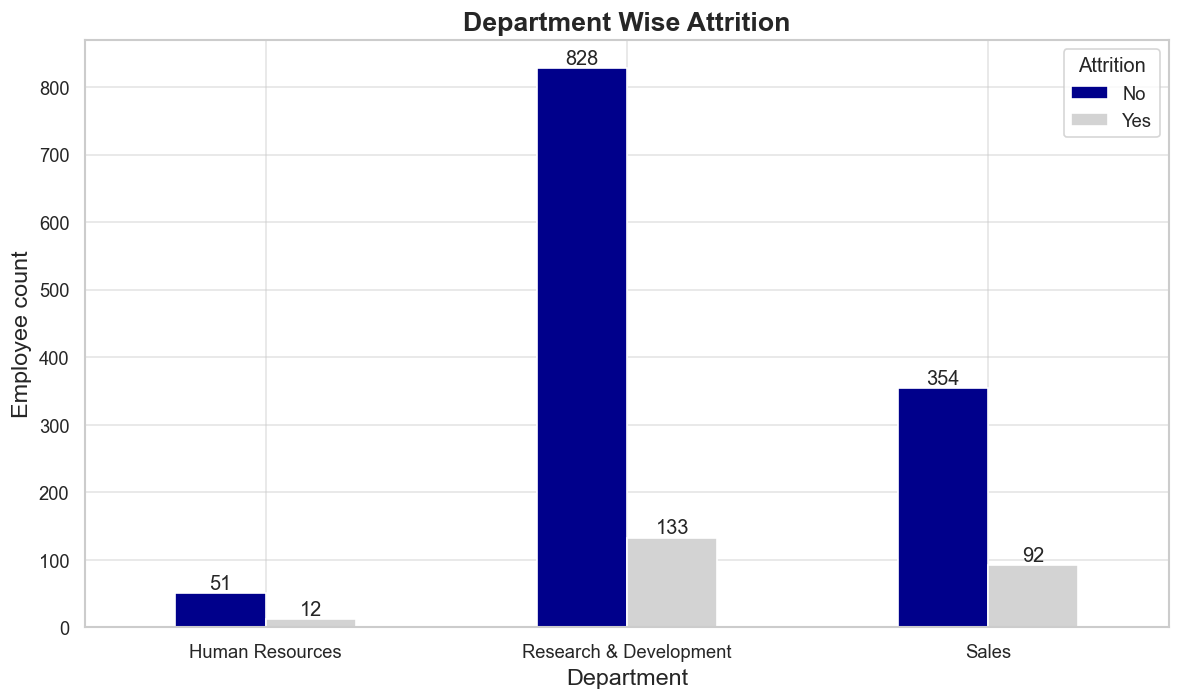

In [45]:
# Compare the two categorial variables
dept_att = pd.crosstab(data["Department"],data["Attrition"])

# Plot the chart
ax = dept_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Department Wise Attrition")
plt.xlabel("Department")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()



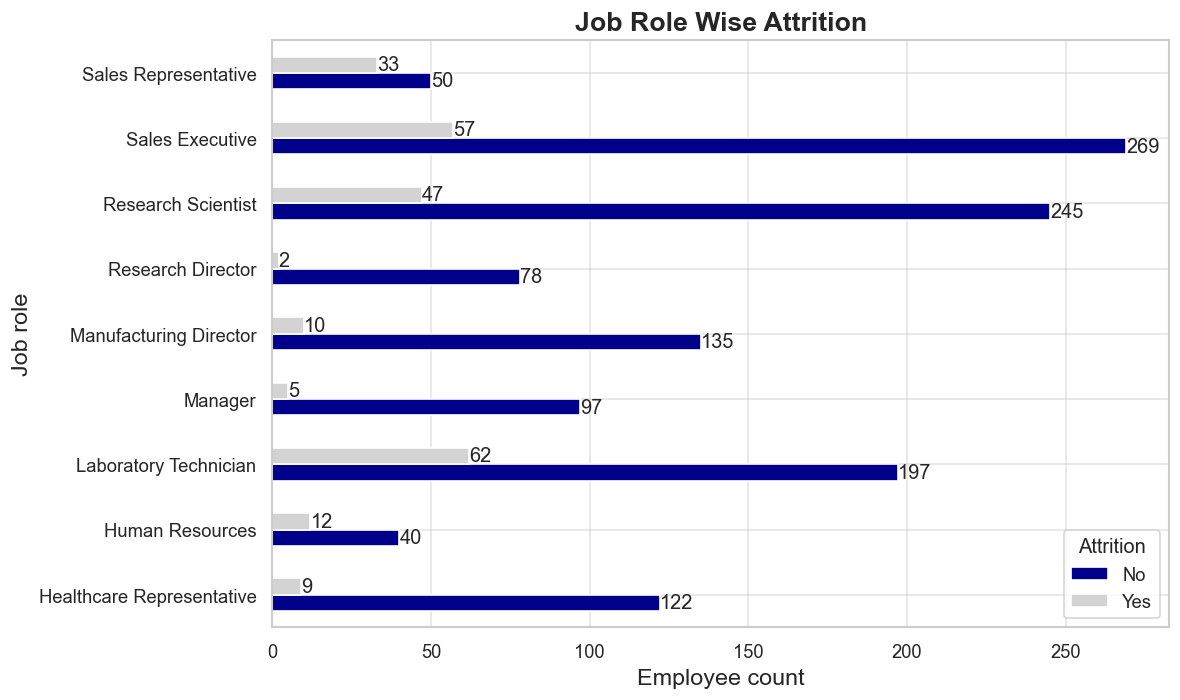

In [46]:
# Compare the two categorial variables
role_att = pd.crosstab(data["JobRole"],data["Attrition"])

# Plot the chart
ax = role_att.plot(kind = "barh",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Job Role Wise Attrition")
plt.xlabel("Employee count")
plt.ylabel("Job role")


plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

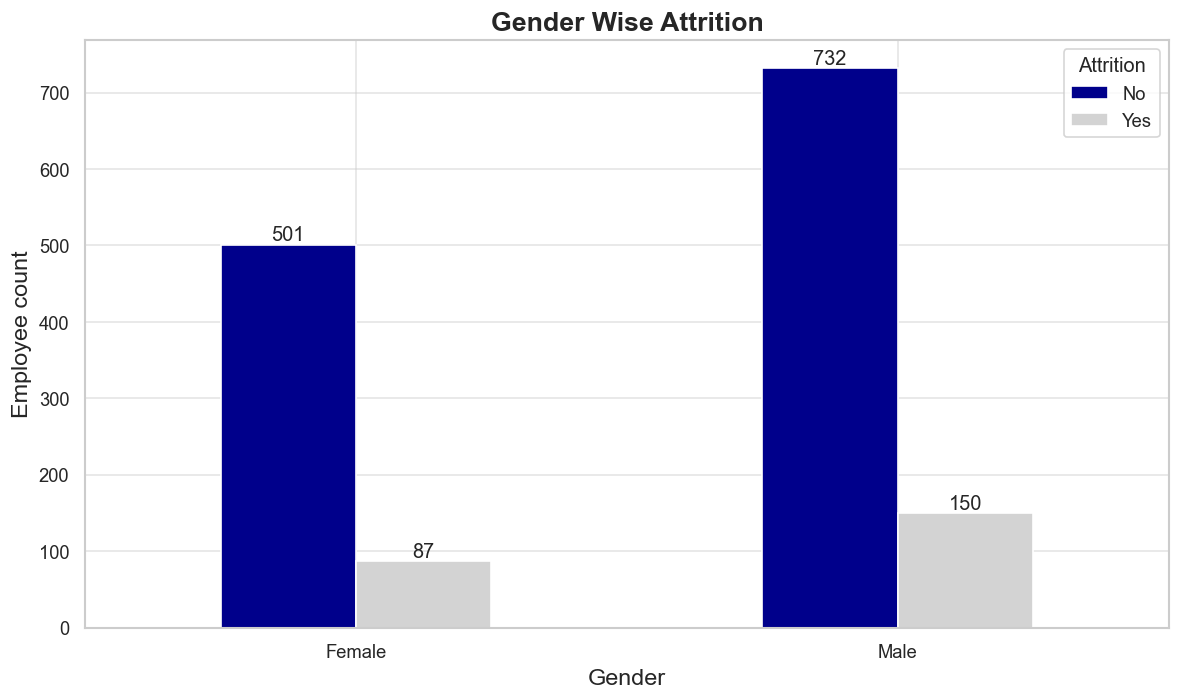

In [47]:
# Compare the two categorial variables
gender_att = pd.crosstab(data["Gender"],data["Attrition"])

# Plot the chart
ax = gender_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Gender Wise Attrition")
plt.xlabel("Gender")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

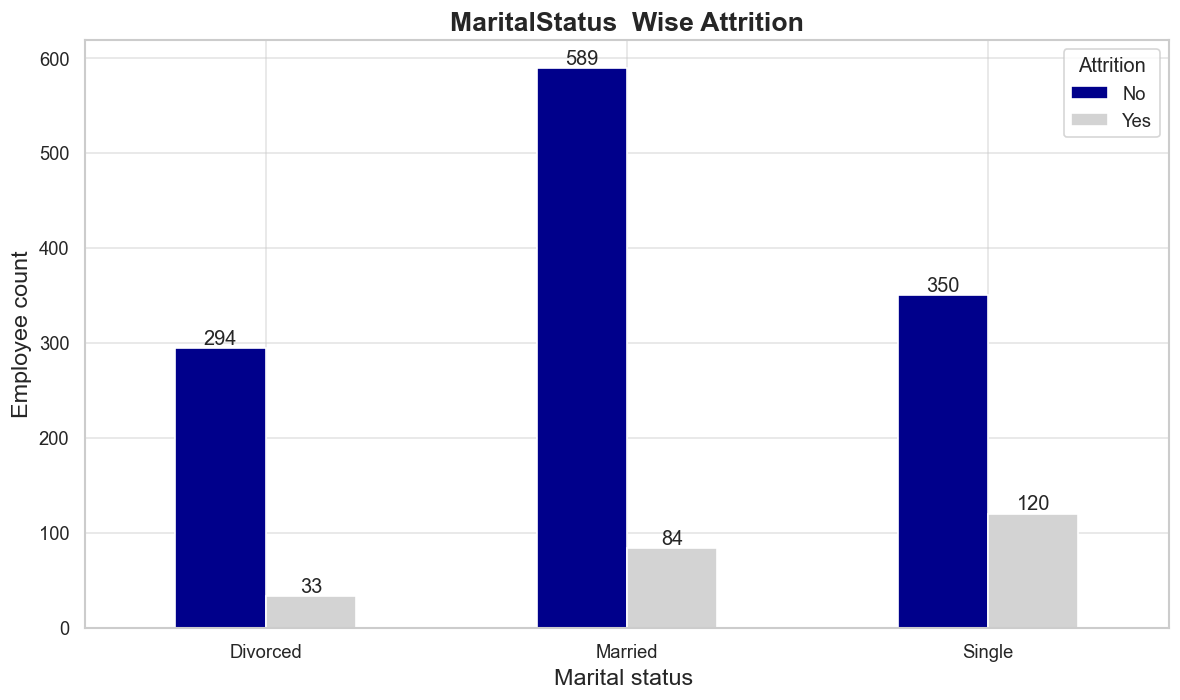

In [48]:
# Compare the two categorial variables
marital_att = pd.crosstab(data["MaritalStatus"],data["Attrition"])

# Plot the chart
ax = marital_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("MaritalStatus  Wise Attrition")
plt.xlabel("Marital status ")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

### Key insights:
- Attrition is highest in the Sales department, particularly among employees in the Sales Representative role. Most of the employees leaving are single females.

2 . OVERTIME VS ATTRITION

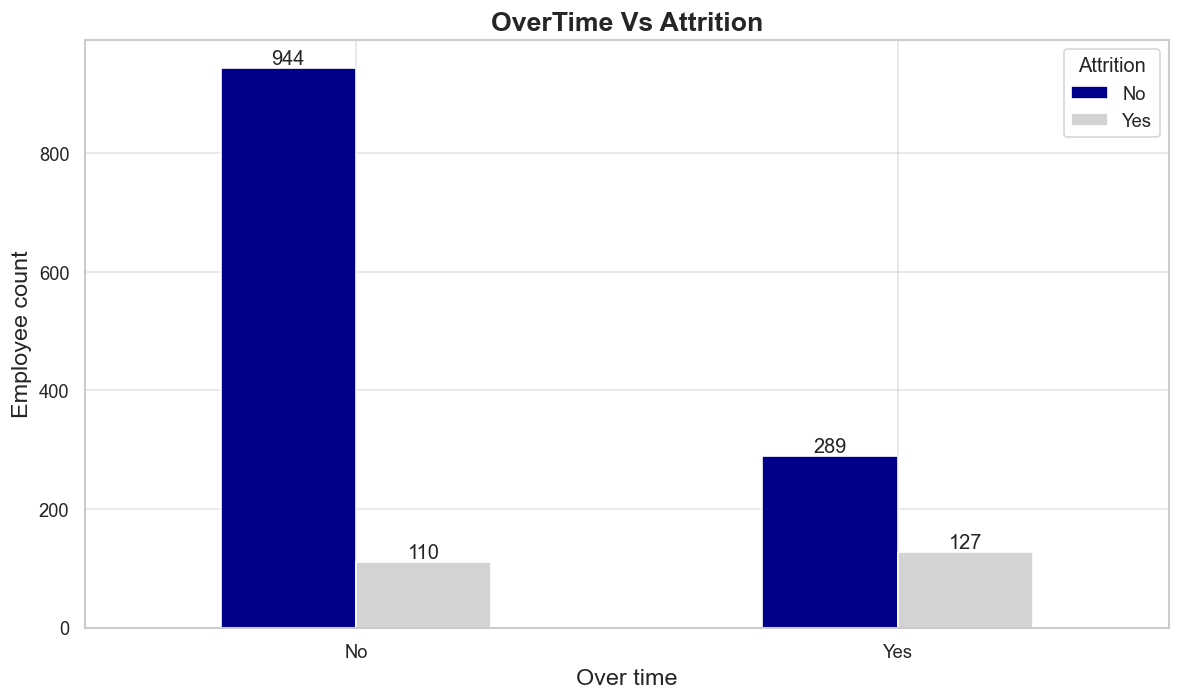

In [49]:
# Group the columns using .size().unstack()
time_att = data.groupby(["OverTime","Attrition"]).size().unstack()

# Plot the chart
ax = time_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("OverTime Vs Attrition")
plt.xlabel("Over time")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

### Key insights:
- Attrition is higher among employees who work overtime, indicating that extended working hours may contribute to increased employee turnover.
- Monitor and reduce excessive overtime by balancing workloads across teams.

3 . SALARY VS ATTRITION

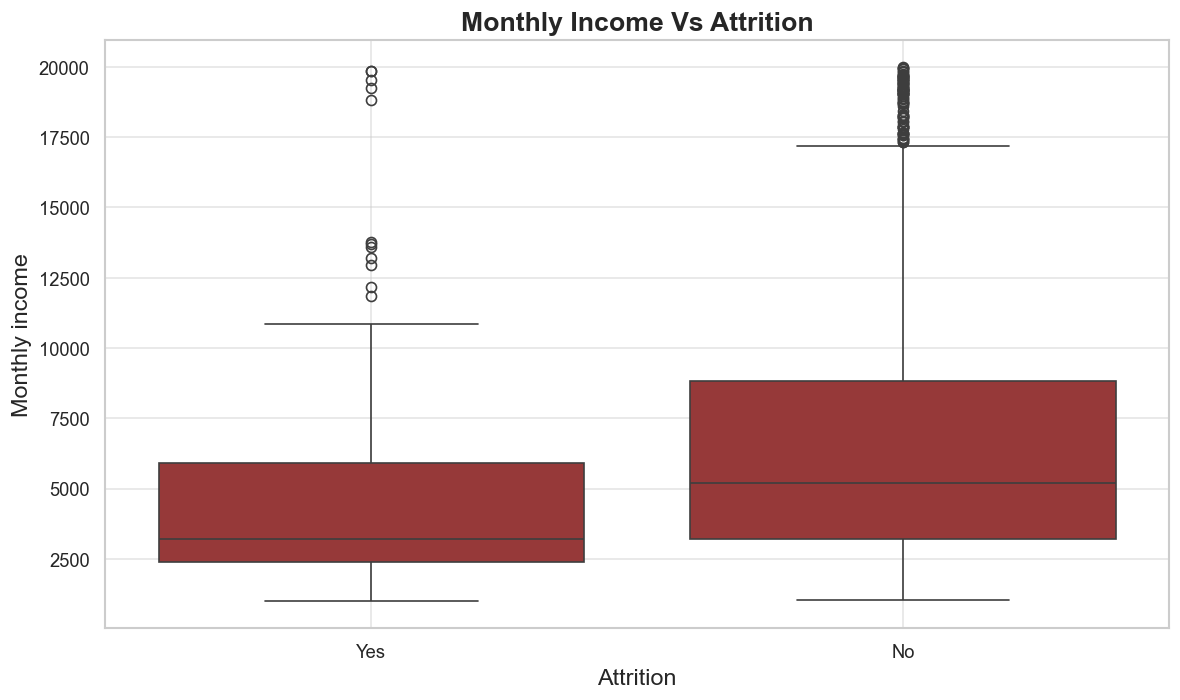

In [50]:
# Group the columns using .size().unstack()
salary_att = data.groupby(["MonthlyIncome","Attrition"]).size().unstack(fill_value=0)
 
# Plot the chart
sns.boxplot(data = data,x = "Attrition",y = "MonthlyIncome",color = "brown")
plt.title("Monthly Income Vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly income")

plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

### Key insights:
- Employees with lower incomes exhibit higher attrition rates. Approximately 50% of all attrition cases occur among employees earning less than 3,000.
- Introduce performance-based incentives, bonuses, or recognition programs for lower-income employees.


4 . JOB SATISFACTION VS ATTRIITION

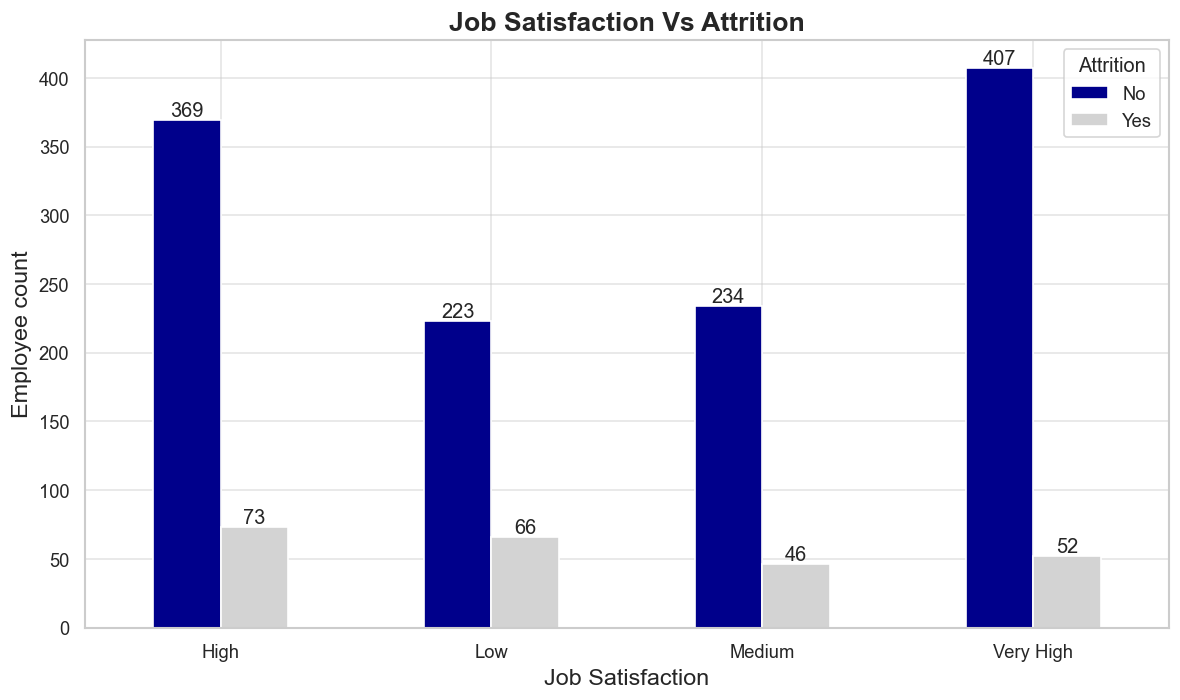

In [51]:
# Change the dtype of the column
data["JobSatisfactionLabel"] = data["JobSatisfaction"].map({1:"Low",2:"Medium",3:"High",4:"Very High"})

# Group the Columns
job_att = data.groupby(["JobSatisfactionLabel","Attrition"]).size().unstack()

# Plot the chart
ax = job_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Job Satisfaction Vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()



### Key insights:
- Employees with lower job satisfaction exhibit significantly higher attrition rates, indicating a strong relationship between employee satisfaction and retention.
- The organization should actively collect employee feedback and address workplace concerns to improve job satisfaction and reduce attrition

5 . WORK-LIFE BALANCE VS ATTRITION

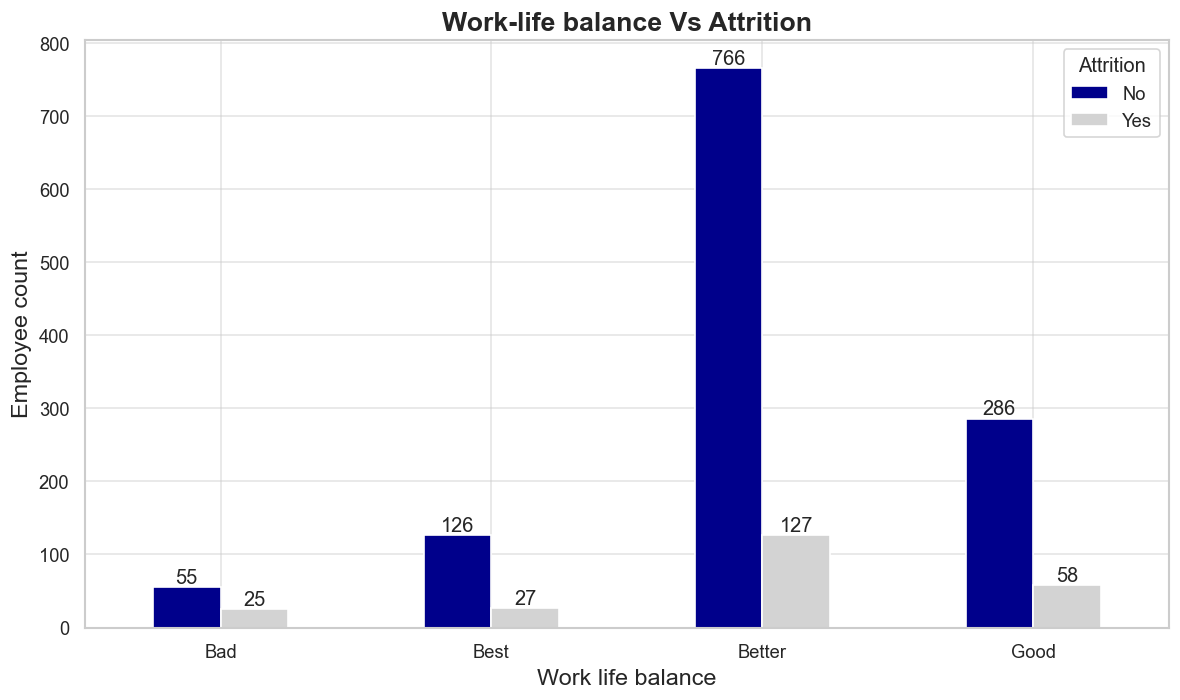

In [52]:
# Change the dtype of the column
data["WorkLifeBalanceLabel"] = data["WorkLifeBalance"].map({1:"Bad",2:"Good",3:"Better",4:"Best"})

# Group the Columns
work_att = data.groupby(["WorkLifeBalanceLabel","Attrition"]).size().unstack()

# Plot the chart
ax = work_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Work-life balance Vs Attrition")
plt.xlabel("Work life balance")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

### Key insights:
- Poor work-life balance is strongly associated with increased employee attrition.
- Introducing wellness programs, periodic breaks, and team-building activities may help reduce employee stress and improve retention.

6 . AGE GROUP ANALYSIS

In [53]:
def age_group(age):
    if age < 30 :
        return "Young"
    elif age < 50 :
        return "Middle"
    else :
        return "Senior"

# Convert the dtype to str
data["AgeLabel"] = data["Age"].apply(age_group)

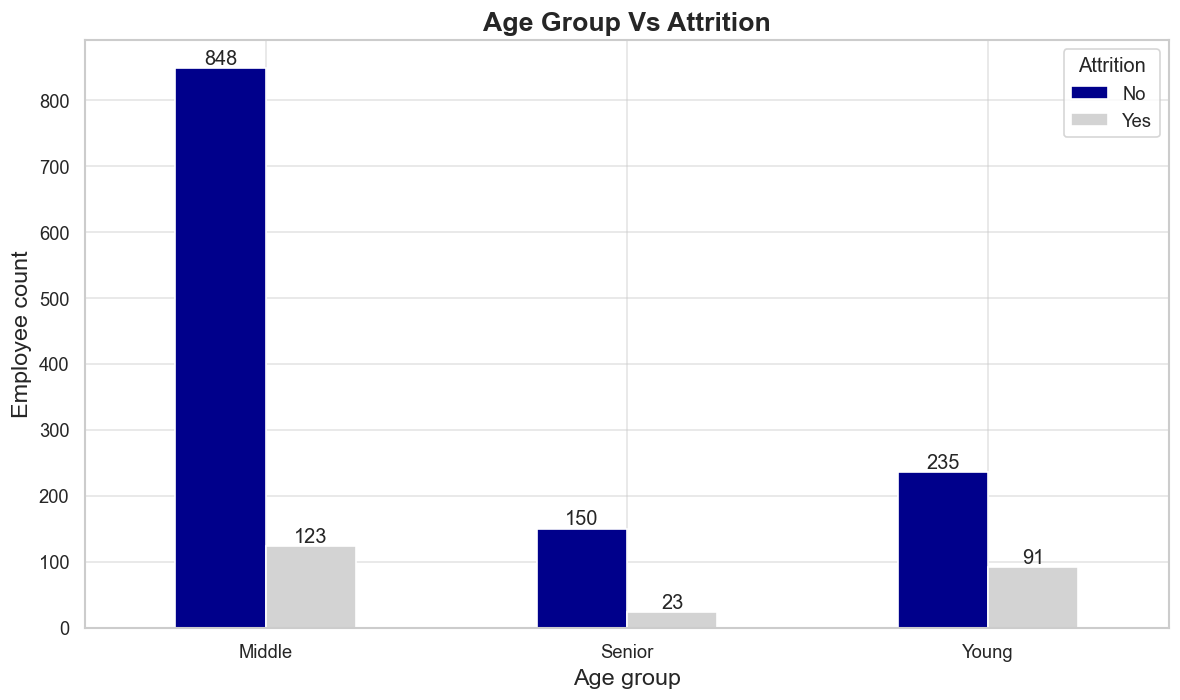

In [54]:
# Group the columns
age_att = data.groupby(["AgeLabel","Attrition"]).size().unstack()

# Plot the chart
ax = age_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Age Group Vs Attrition")
plt.xlabel("Age group")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

### Key insights:
- Employees under the age of 30 exhibit a higher attrition rate, indicating that younger employees are more likely to leave the organization.
- Implementing performance-based salary increments aligned with industry benchmarks can help improve employee satisfaction and retention among younger talent.

7 . YEARS AT COMPANY VS ATTRITION :

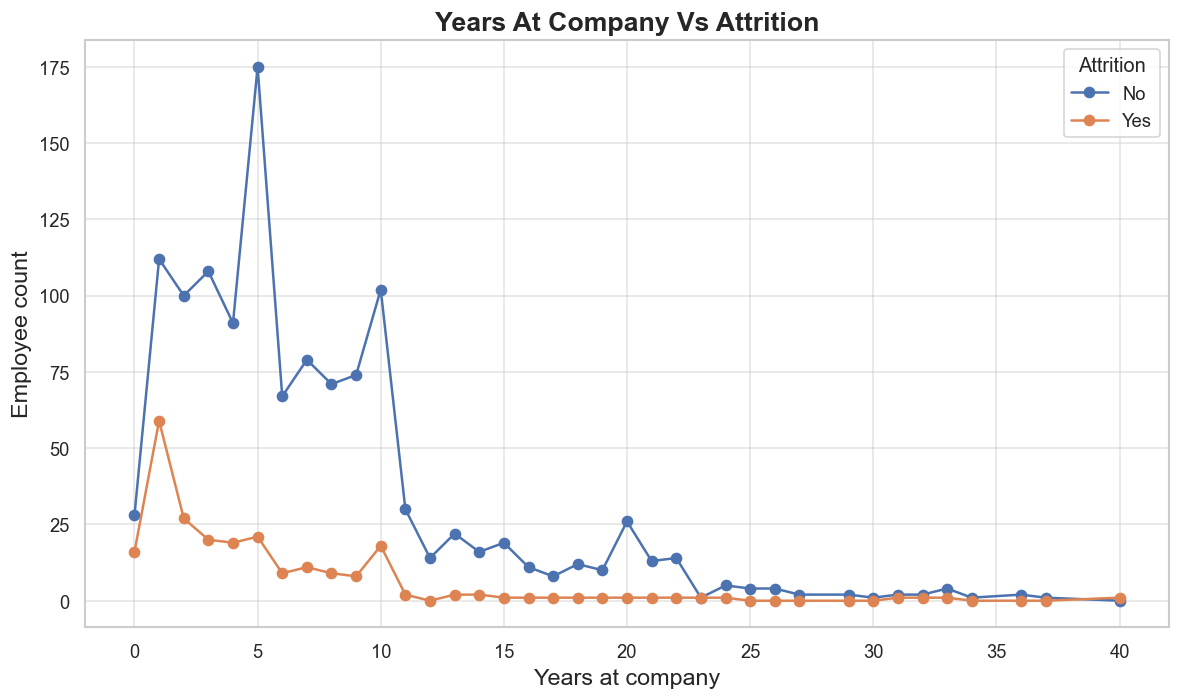

In [55]:
# Group the columns
years_att = data.groupby(["YearsAtCompany","Attrition"]).size().unstack(fill_value=0)

# Plot the chart
years_att.plot(kind = "line",marker = "o")

plt.title("Years At Company Vs Attrition")
plt.xlabel("Years at company")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()

### Key insights:
- The majority of employee attrition occurs within the first few years of joining.
- Provide clear career growth opportunities and development plans to increase employee engagement and commitment.

8 . PROMOTION ANALYSIS

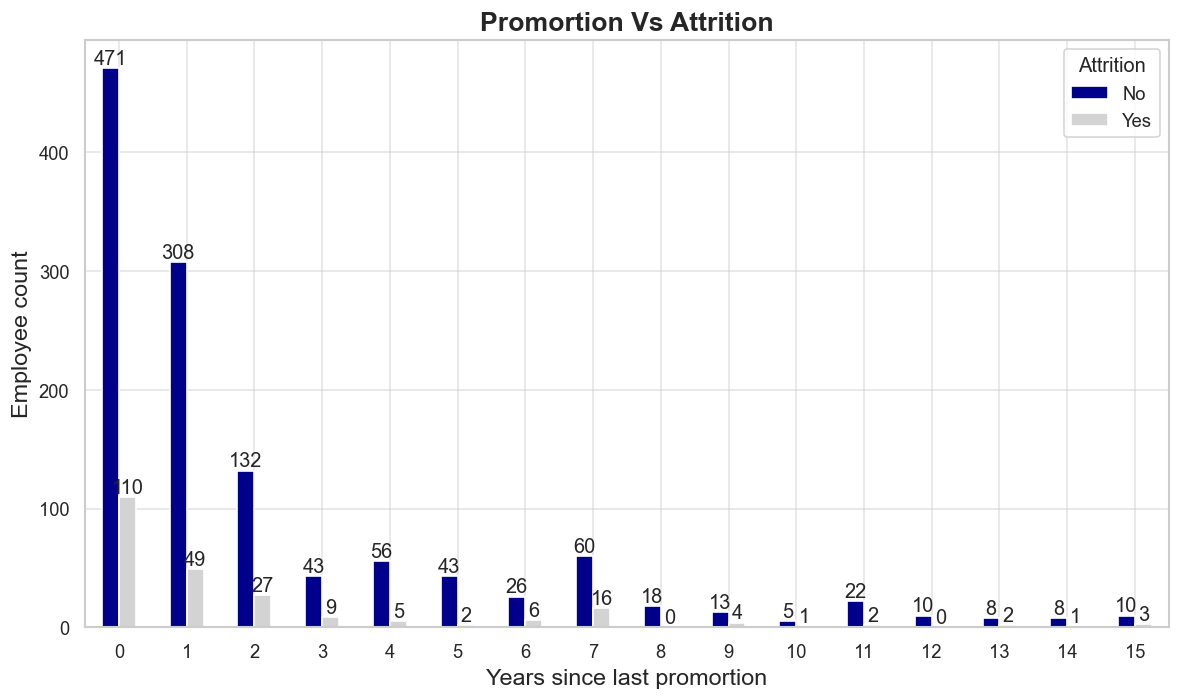

In [56]:
# Group the columns
promortion_att = data.groupby(["YearsSinceLastPromotion","Attrition"]).size().unstack(fill_value=0)

# Plot the chart
ax = promortion_att.plot(kind = "bar",color = ["darkblue","lightgrey"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Promortion Vs Attrition")
plt.xlabel("Years since last promortion")
plt.ylabel("Employee count")

plt.xticks(rotation = 0)
plt.grid(True,alpha = 0.5)

plt.tight_layout()
pdf.savefig()
plt.show()


### Key insights:
- Promotions do not appear to have a significant impact on reducing employee attrition, suggesting that factors other than career advancement may play a larger role in employees' decisions to leave the organization

In [57]:
pdf.close()